# Telco Customer Churn — CatBoost & Interpretability

Цель ноутбука:

- обучить модель CatBoost для задачи прогнозирования оттока клиентов;
- сравнить качество CatBoost с baseline-моделями (Logistic Regression / Random Forest);
- проанализировать важность признаков и их вклад в предсказания (feature importance / SHAP);
- сформировать бизнес-выводы о ключевых драйверах churn.


In [11]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier, Pool

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8")


In [12]:
TARGET_COL = "churn_value"

train = pd.read_csv("../data/processed/train.csv")
valid = pd.read_csv("../data/processed/valid.csv")
test  = pd.read_csv("../data/processed/test.csv")

X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]

X_valid = valid.drop(columns=[TARGET_COL])
y_valid = valid[TARGET_COL]

X_test  = test.drop(columns=[TARGET_COL])
y_test  = test[TARGET_COL]

X_train.shape, X_valid.shape, X_test.shape


((4225, 24), (1409, 24), (1409, 24))

Используем уже подготовленные выборки из предыдущих ноутбуков:

- признаки очищены и дополнены бизнес-фичами (`is_new_customer`, `num_addon_services`, `avg_monthly_revenue` и т.д.);
- удалены ID, географические признаки и признаки с утечкой таргета (`churn_score`, `churn_reason`, `cltv`);
- разбиение на `train / valid / test` выполнено со стратификацией по `churn_value`.


In [13]:
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

num_features, cat_features


(['tenure_months',
  'monthly_charges',
  'total_charges',
  'is_new_customer',
  'is_long_contract',
  'has_internet',
  'num_addon_services',
  'avg_monthly_revenue'],
 ['gender',
  'senior_citizen',
  'partner',
  'dependents',
  'phone_service',
  'multiple_lines',
  'internet_service',
  'online_security',
  'online_backup',
  'device_protection',
  'tech_support',
  'streaming_tv',
  'streaming_movies',
  'contract',
  'paperless_billing',
  'payment_method'])

CatBoost особенно хорошо подходит для этой задачи, потому что:

- умеет напрямую работать с категориальными признаками, без явного one-hot кодирования;
- устойчив к разным типам признаков и пропускам;
- даёт хорошее качество "из коробки" и удобные средства интерпретации
  (`feature_importance`, `ShapValues`).


In [14]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features
)

valid_pool = Pool(
    data=X_valid,
    label=y_valid,
    cat_features=cat_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features
)


In [15]:
def evaluate_cat_model(model, X, y, name="model"):
    """
    Оценивает CatBoost-модель по ROC-AUC и PR-AUC (Average Precision).
    """
    proba = model.predict_proba(X)[:, 1]

    roc = roc_auc_score(y, proba)
    pr  = average_precision_score(y, proba)

    print(f"{name:25s} | ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")
    return {"model": name, "roc_auc": roc, "pr_auc": pr}


## CatBoost — базовая модель

Начнём с разумной базовой конфигурации:

- `loss_function="Logloss"` и `eval_metric="AUC"` для задачи бинарной классификации;
- `depth=6`, `learning_rate=0.1`, `n_estimators=500` — типичные стартовые параметры;
- `random_seed` и `use_best_model=True` для воспроизводимости и выбора лучшей итерации по валидации;
- `class_weights` можно использовать для компенсации дисбаланса (≈27% churn).


In [16]:
cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    depth=6,
    learning_rate=0.1,
    n_estimators=500,
    random_seed=RANDOM_STATE,
    class_weights=[1.0, 3.0],
    verbose=100,
    use_best_model=True,
    train_dir="../logs"   # ← ВАЖНО
)


cat_model.fit(
    train_pool,
    eval_set=valid_pool,
    verbose=100
)


0:	test: 0.8197473	best: 0.8197473 (0)	total: 29.7ms	remaining: 14.8s
100:	test: 0.8545493	best: 0.8556524 (52)	total: 2.91s	remaining: 11.5s
200:	test: 0.8496370	best: 0.8556524 (52)	total: 6s	remaining: 8.92s
300:	test: 0.8477150	best: 0.8556524 (52)	total: 9.18s	remaining: 6.07s
400:	test: 0.8455579	best: 0.8556524 (52)	total: 12.4s	remaining: 3.06s
499:	test: 0.8444922	best: 0.8556524 (52)	total: 15.5s	remaining: 0us

bestTest = 0.8556524323
bestIteration = 52

Shrink model to first 53 iterations.


In [17]:
res_cat_train = evaluate_cat_model(cat_model, X_train, y_train, "CatBoost (train)")
res_cat_valid = evaluate_cat_model(cat_model, X_valid, y_valid, "CatBoost (valid)")
res_cat_test  = evaluate_cat_model(cat_model, X_test,  y_test,  "CatBoost (test)")

res_cat_train, res_cat_valid, res_cat_test


CatBoost (train)          | ROC-AUC: 0.8836 | PR-AUC: 0.7228
CatBoost (valid)          | ROC-AUC: 0.8557 | PR-AUC: 0.6744
CatBoost (test)           | ROC-AUC: 0.8543 | PR-AUC: 0.6778


({'model': 'CatBoost (train)',
  'roc_auc': 0.883575737789345,
  'pr_auc': 0.7228012652113257},
 {'model': 'CatBoost (valid)',
  'roc_auc': 0.8556524322508977,
  'pr_auc': 0.6744450796957855},
 {'model': 'CatBoost (test)',
  'roc_auc': 0.8543374925727867,
  'pr_auc': 0.6778226218112724})

### Качество CatBoost

CatBoost показывает стабильное и высокое качество:

- **Train:** ROC-AUC ≈ 0.88, PR-AUC ≈ 0.72  
- **Valid:** ROC-AUC ≈ 0.856, PR-AUC ≈ 0.674  
- **Test:** ROC-AUC ≈ 0.854, PR-AUC ≈ 0.678  

Поскольку использован `use_best_model=True`, модель автоматически
оканчивает обучение на лучшей итерации по валидации:

- `bestIteration = 52`, `bestTest ≈ 0.856` (ROC-AUC на valid),
- финальная модель усечена до первых 53 деревьев.

Переобучение контролируется: качество на валидации и тесте почти совпадает,
а разница с train остаётся разумной для бустинга.

Если сравнивать с baseline-моделями из ноутбука `03_modeling_baselines`:

- Logistic Regression даёт ROC-AUC на test ≈ **0.854**, PR-AUC ≈ **0.665**;
- Random Forest — ROC-AUC ≈ **0.853**, PR-AUC ≈ **0.662**;
- CatBoost — ROC-AUC ≈ **0.854**, PR-AUC ≈ **0.678**.

CatBoost чуть улучшает качество по PR-AUC (важной метрике для редкого класса churn)
и остаётся на уровне лучших baseline’ов по ROC-AUC.


## Анализ важности признаков (Feature Importance)

Посмотрим, какие признаки оказывают наибольшее влияние
на предсказания CatBoost-модели.


In [18]:
feature_importances = cat_model.get_feature_importance(train_pool)
feat_imp_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": feature_importances
}).sort_values("importance", ascending=False)

feat_imp_df.head(15)


,feature,importance
3,dependents,23.0059
20,is_long_contract,17.6695
4,tenure_months,9.2502
14,contract,5.8870
18,total_charges,5.2838
8,online_security,4.7610
7,internet_service,4.6245
13,streaming_movies,3.6482
23,avg_monthly_revenue,3.5777
11,tech_support,3.4647


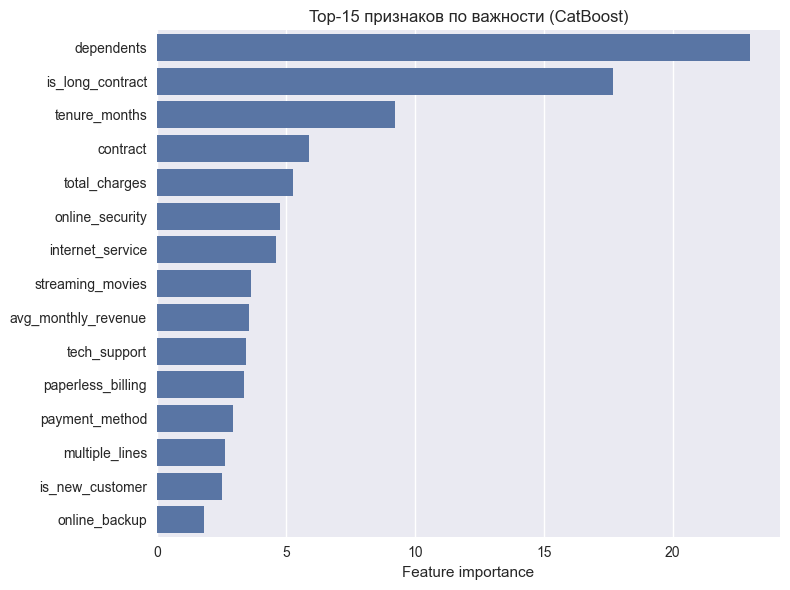

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp_df.head(15),
    x="importance",
    y="feature"
)
plt.title("Top-15 признаков по важности (CatBoost)")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


Среди наиболее важных признаков (топ-15) модель выделяет:

- **`dependents`** — наличие/отсутствие иждивенцев;
- **`is_long_contract`** и **`contract`** — тип и длительность контракта;
- **`tenure_months`** — стаж клиента;
- **`total_charges`** и **`avg_monthly_revenue`** — накопленная и средняя выручка;
- **`internet_service`**, **`online_security`**, **`tech_support`**, 
  **`streaming_movies`** — наличие интернет-услуг и доп. сервисов;
- **`paperless_billing`** и **`payment_method`** — способ и формат оплаты;
- **`multiple_lines`**, **`is_new_customer`**, **`online_backup`**.

Несколько наблюдений:

- Тип контракта и стаж (`is_long_contract`, `contract`, `tenure_months`)
  оказывают заметное влияние на churn, что согласуется с EDA:
  помесячные контракты и новые клиенты — зона повышенного риска.
- Цена и выручка (`monthly_charges`, `total_charges`, `avg_monthly_revenue`)
  важны для модели, но не доминируют — churn определяется не только тарифом,
  но и структурой услуг.
- Дополнительные сервисы (`online_security`, `tech_support`, `streaming_movies`,
  `online_backup`) входят в топ-фичей, что подчёркивает роль “пакетности” и
  глубины использования продукта.
- Признак `dependents` становится неожиданно важным фактором: наличие иждивенцев
  может быть прокси для семейных клиентов, у которых потребность в связи выше
  и решения о смене провайдера принимаются реже. Это гипотеза, которую можно
  дополнительно проверить в отдельном анализе.


## Локальная интерпретация: SHAP values

Для более детального понимания того, почему модель относит конкретного клиента
к группе риска, используем SHAP-значения для CatBoost.

На практике для отчётности достаточно рассмотреть небольшой поднабор клиентов
(например, 500–1000 наблюдений), чтобы не перегружать визуализации.


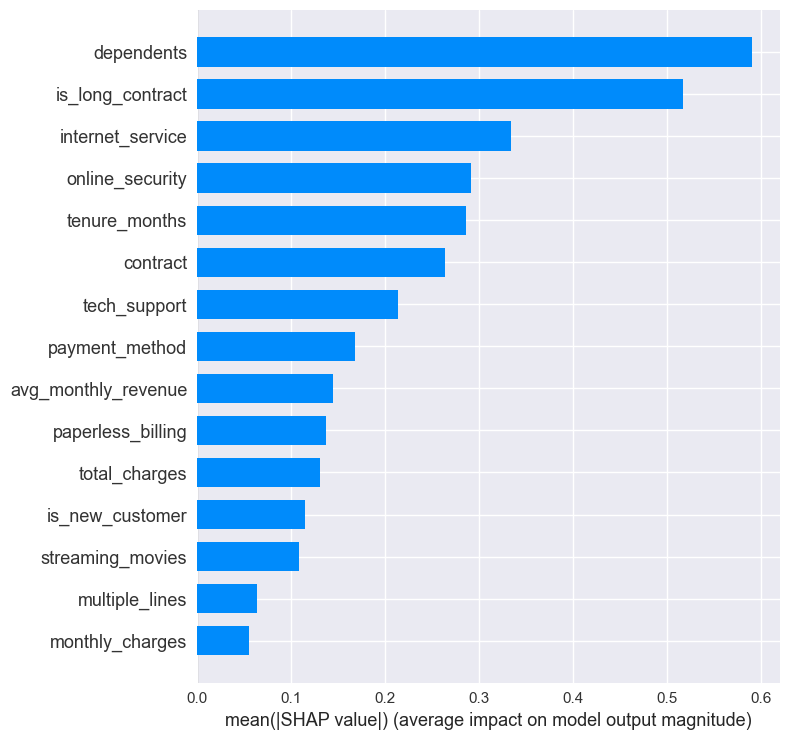

In [20]:
import shap

# берём подвыборку для интерпретации
shap_sample = X_valid.sample(n=500, random_state=RANDOM_STATE)
shap_sample_pool = Pool(shap_sample, cat_features=cat_features)

# Получаем SHAP-значения от CatBoost
shap_values = cat_model.get_feature_importance(
    shap_sample_pool,
    type="ShapValues"
)

# Последний столбец в shap_values — это base value (ожидаемое значение),
# остальные соответствуют признакам.
shap_values_for_plot = shap_values[:, :-1]

explainer = shap.Explainer(cat_model)
# Для совместимости с новыми версиями shap/catboost можно обернуть так:
# explainer = shap.TreeExplainer(cat_model)

shap.summary_plot(
    shap_values_for_plot,
    shap_sample,
    plot_type="bar",
    max_display=15
)


SHAP-график показывает **средний абсолютный вклад признаков в предсказания модели**:

- На первых позициях снова находятся `dependents`, `is_long_contract`,
  `internet_service`, `online_security`, `tenure_months` и `contract` —
  это подтверждает выводы по feature importance.
- Высокие значения SHAP у `tech_support`, `payment_method`,
  `avg_monthly_revenue`, `paperless_billing` и `total_charges`
  означают, что изменения по этим признакам заметно сдвигают вероятность churn
  вверх или вниз.
- Признаки `is_new_customer`, `streaming_movies`, `multiple_lines`,
  `monthly_charges` пусть и не являются самыми “тяжёлыми”, но всё равно
  вносят чувствимый вклад в финальное решение модели.

Вместе с feature importance, SHAP-анализ показывает, что модель
опирается на понятные бизнес-факторы: тип контракта, стаж, структуру услуг,
ценовую нагрузку и характеристики платежей.


## Итоги ноутбука с CatBoost

- Построена и обучена модель **CatBoostClassifier** для задачи прогнозирования churn
  на подготовленных табличных данных Telco.
- Модель обучалась с использованием валидационного набора и флага `use_best_model=True`,
  в результате чего выбран лучший ансамбль из **53 деревьев** (bestIteration ≈ 52).
- Качество на независимой тестовой выборке:
  - ROC-AUC ≈ **0.854**,
  - PR-AUC ≈ **0.678**,  
  что немного лучше baseline Logistic Regression и Random Forest, особенно
  по PR-AUC для класса churn.
- Анализ **feature importance** и **SHAP-значений** показал, что ключевые драйверы churn:
  - тип и длительность контракта (`contract`, `is_long_contract`),
  - стаж клиента (`tenure_months`, `is_new_customer`),
  - наличие интернет-услуг и дополнительных сервисов (`internet_service`,
    `online_security`, `tech_support`, `streaming_movies`, `online_backup`),
  - ценовая нагрузка (`monthly_charges`, `avg_monthly_revenue`, `total_charges`),
  - формат и способ оплаты (`paperless_billing`, `payment_method`),
  - а также демографический фактор `dependents`.

С точки зрения бизнеса CatBoost-модель позволяет:

- приоритизировать клиентов для retention-кампаний (на основе предсказанной
  вероятности churn);
- формировать гипотезы по продукту: усиление долгосрочных контрактов, развитие
  доп. сервисов, перевод клиентов на автосписание;
- использовать интерпретацию (feature importance + SHAP) для объяснения решений
  бизнес-командам и стейкхолдерам.

Дальнейшие шаги:
- перейти к настройке **порогов классификации** под разные бизнес-сценарии
  (максимальный recall vs более высокий precision);
- оценить потенциальный эффект retention-кампаний при использовании модели
  (ожидаемое число "спасённых" клиентов и стоимость контакта).
